<a href="https://colab.research.google.com/github/DevWebWacky/Certification-Projects/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**EXPLAINING ABOVE TEXT**
Python itself is small. Most ML work relies on libraries, these libraries are prebuilt toolkits.



*   **Pandas**: pandas is used for working with datasets. It is like an Excel spreadsheet inside Python. It allows you to load datasets, view tables, cleam data, and manipulate columns
*   **numpy**: numpy handles numerical computation. ML models work with numbers, not text. Numpy helps Python do fast math with arrays.


*   **matplotlib**: This library creates graphs and plots.
*   **seaborn**: seaborn is built on matplotlib but makes cleaner statiscal visuals. such include correlation heatmaps, distribution plots, boxplots.







STEP 2: LOAD A DIABETES DATASET

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(url, names=columns)
data.head()

,pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


For the code above, we named the columns because it did not have headings. But if your dataset has an heading you do not have to name the column. so you just load it with the code: data = pd.read_csv.
If you have manually named them, you can access the named columns using the code: data.columns.

In [ ]:
data.shape

(768, 9)

The number above tells us the number of rows and columns in your data. In the case above, we have 768 rows or patients and 9 columns or variables recorded for each patient. Each row represents one patient and each column represents one clinical feature or the outcome.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


The above code: data.info() gives you a structural summary of the dataset. It tells you the number of rows, column names, data types, missing values. If there is a missing value in a column, it will differ from the rest. Missing data is very common in healthcare datasets, so we always check for it.
int64 simply means integer numbers and float is used for numbers with decimals. So when checking your data, note that sometimes missing measurements are stored as 0 instead of blank. so you must clean them effectively because biologically, these values are impossible and are not actual measurements.

In [ ]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


The Value above means 500 patients do not have diabetes and 268 patients have diabetes. This tells us about class balance and ideally both classes would be close in size but in real medical data, that almost never happens. This is called Mild Class Imbalance.

Why imbalance can affect models?
Imagine a dataset like 950 healthy and 50 diseased, a lazy model would predict everyone as healthy. This model would predict zero real patient. This is why in healthcare, sensitivity, specificity, ROC-AUC is really important not just accuracy.

**Lets visualise the class distribution**

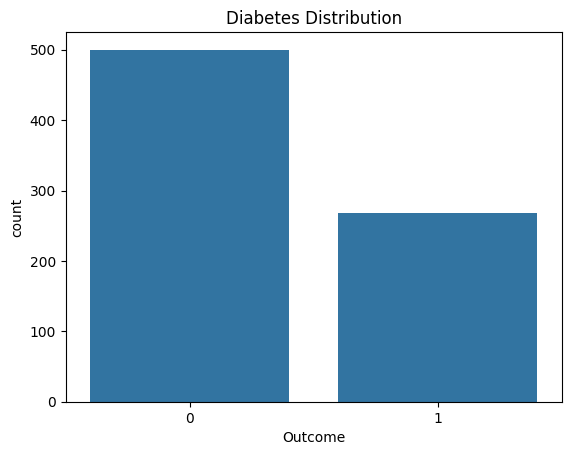

In [ ]:
import pandas as pd
import seaborn as sns
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(url, names=columns)
sns.countplot(x='Outcome', data=data)
plt.title("Diabetes Distribution")
plt.show()

**Now let us understand the numerical behaviour of the variables (Summary Statistics)**

In [ ]:
data.describe()

,pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The above gives a statistical summary of all numerical columns.
Summary helps us identify impossible values or data quality issues.

**let us look for something suspecious**

In [ ]:
data[['Glucose', 'BloodPressure', 'BMI', 'Insulin']].min()

,0
Glucose,0.0
BloodPressure,0.0
BMI,0.0
Insulin,0.0


The above code shows the minimum values for some clinical variables. If you see 0, then it is a major clue that a data is missing. We know that it is impossible to have a glucose, BP, BMI, and Insulin levels of 0. So this usually means that the measurements was not recorded, thus it was stored as 0 in the dataset. The next best step is to convert the zeros intoamissing values (NaN) so the model understands they are unknown.

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols] = data[cols].replace(0, np.nan)
data.isnull().sum()

,0
pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Explaining the code above:


*   The first line of the code tells where 0 is biologically impossible, so you have to select them.
*   The second line of code replaces 0 with NaN. NaN means not a number and python uses it to represent missing data.


*   The third line of code tells us how many missing values exist in each column.

So from the results, we have the missing values attached to these numbers

**Interpretation**


1.   Glucose (5 missing) is very good and BMI (11 missing) is also acceptable. BloodPressue (35 missing) is still usable, but needs handling.
2.   SkinThickness of approximately 30% and Insulin of approximately 50% missing needs real decision so as not to negatively affect the model.

What this really means that not all tests are done for all patients, some tests are expensive (like insulin), and some measurements are skipped. so this kind of dataset is expected in healthcare.

**KEY ML DECISION**
1. Drop the column completely: In this case, you can remove the insulin completely. This is good when too many values are missing and not critical clinically.
2. Fill (impute) missing values: Replace missing values with something like mean, median (better for medical data).
3. Advanced imputation.

The best of the 3 is to fill it in using median because medical data often has outliers, and median is more stable than mean.






In [ ]:
data.fillna(data.median(), inplace=True)
data.isnull().sum()

,0
pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


The code above replaces all missing values with the median of each column. inplace=True means it updates the dataset directly.

This step is important because ML models cannot handle missing values and they require complete numerical input. So it is mandatory before modeling.

**MODELS DEVELOPMENT**

STEP 1: We are going to predict if a patient has diabetes or not. So we have to first separate features and label.

In [ ]:
x = data.drop('Outcome', axis=1)
y = data['Outcome']

Explanation:
x means features (inputs). We remove or drop the outcome column because we do not want to give the answer to the model and so it must learn to predict it. so x now contains other variables but not outcome.
The y is the label (target) which is what we want to predict. 0 = no diabetes and 1 = diabetes.

STEP 2: Split into training and testing data

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Explanation: So we are splitting the dataset into 80% (training set) and 20% (test set). The training data is what the model will use to learn patterns and the test set is what the model will be evaluated with unseen patients. the random_state value ensures that the test and training sets get the same split every time, without it, results change randomly.

LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

Explanation: This model is simple, interpretable, and very common in healthcare. The model.fit(x_train, y_train) is where the magic happens, the model looks at patient data (x_train) and looks at the outcome (y_train) and learns patterns like: higher glucose + higher BMI means higher diabetes risk.

Let us make some predictions

In [ ]:
y_pred = model.predict(x_test)

The model now takes new patients (x_test) and predicts 0 = no diabetes and 1 = diabetes. Now let us evaluate the model

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


This compares (y_test) and predicted outcomes (y_pred) and gives percentage of correct predictions. The accuracy here 0.7532... means ~75.3% accuracy. Out of 100 patients, the model correctly predicts about 75. For a simple model like this, it is a good starting point.

However, accuracy alone is not enough. In healthcare, it can be misleading. Thus we need to answer: How many actual diabetic patients did we catch, how many healthy patients did we wrongly flag?

CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[82 17]
 [21 34]]


TN (True Negative) which is 82 means the model correctly predicted no diabetes. FP (False Positive) which is 17 means the model predicted diabetes but actually healthy. FN (False Negative) which is 21 means the model missed a diabetic patient. TP (True Positive) which is 34 means the model correctly detected diabetes.

This is important because in healthcare FN are dangerous and it means missed diagnosis. And FP are annoying which are unneccessary tests.

NOW TO GET THE FULL PERFORMANCE

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



Explanation: Focus on "Recall" which is sensitivity. This tells you how accurately the model detected diabetics and non-diabetics.
Always remember that the model will do prediction based on the test data only and thus in this case, the 20%.

The recall of 0.62 for the class 1 means the model correctly identifies 62% of diabetic patients and missed 38% of the real diabetics and those are the false negatives (21).

This equals the 75% accuracy we had earlier (the model is still decent) but in healthcare missing a disease is usually worse than a false alarm. This is where ML becomes clinical thinking, you now have to ask "Do I want to catch more diabetic patients, even if I increase false positives" If so then you can adjust the threshold. Atm, the model uses a default 0.5 threshold, so we can change the threshold to 0.3, this will increase sensitivity and decrease specificity.

In [ ]:
y_prob = model.predict_proba(x_test)[:, 1]
y_pred_new = (y_prob >= 0.3).astype(int)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))
print(confusion_matrix(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.82      0.65      0.72        99
           1       0.54      0.75      0.63        55

    accuracy                           0.68       154
   macro avg       0.68      0.70      0.67       154
weighted avg       0.72      0.68      0.69       154

[[64 35]
 [14 41]]


Explanation: By lowering the threshold from 0.5 to 0.3, the model is now more agressive in calling someone diabetic. So now we are getting 75% diabetic patients and missing 25% which is better than the former 62%. But the hitch here is that when you increased the recall, false positive also increased. Thus sensitivity is up and specificity is down.

In healthcare ML, there is no perfect model, thus you choose based on context:
If the disease is dangerous, then you have to priorities high sensitivity, and if the treatment is risky and expensive, then prioritise high specificity.

NEXT STEPS: We are now going to look at features that are actually driving the prediction. We have to understand if glucose really is the strongest predictor, does BMI matter, or what about age?

In [ ]:
coefficients = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_[0]})
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.553694
5,BMI,0.101797
0,pregnancies,0.067629
1,Glucose,0.037338
7,Age,0.034603
3,SkinThickness,0.007714
4,Insulin,-0.001669
2,BloodPressure,-0.013234


Explanation: model.coef_ contains the weights the model learned. Each feature gets a number: positive value = increase probability of diabetes, negative value = decrease probability of diabetes. These are just raw logistic regresion coefficients and thus are not a fair importance ranking. So the coefficient size alone does not mean one feature is truly more important than another. Thus we have to standardise the features first, then fit the model again, this way, all variables are on the same scale, and the coefficients become much easier to compare.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x = data.drop('Outcome', axis=1)
y = data['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model2 = LogisticRegression(max_iter=1000)
model2.fit(x_train_scaled, y_train)

coefficients = pd.DataFrame({'Feature': x.columns, 'Coefficient': model2.coef_[0]})
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,Glucose,1.102682
5,BMI,0.688839
7,Age,0.392410
0,pregnancies,0.222978
6,DiabetesPedigreeFunction,0.203635
3,SkinThickness,0.068836
4,Insulin,-0.138252
2,BloodPressure,-0.151540


Explanations:
StandardScaler() makes all features comparable
fit_transform() learns the scaling from training data
transform() applies the same scaling to test data
model2 trains on the scaled data.

This makes the coefficient ranking more meaningful.

The new results showing glucose, BMI, and age as the leading risk factor is more accurate. It just moved from numbers on the screen to aligning with medical reality.

Glucose being the strongest predictor is exactly what we expected. Higher blood glucose = higher likelihood of diabetes. So this must be the top feature.

BMI coming second is also correct. Higher BMI (overweight/obesity) predisposes one to increased risk of diabetes and this aligns with real-world epidemiology.

Age coming third is also correct. older age > higher accumulative risk of developing diabetes.

N/B: Always scale your features before interpreting coefficients.

The next step is to check how good is the model across all threshold. So instead of picking 0.5 or 0.3, we will evaluate everything at once using ROC curve and AUC, which are the most important evaluation tools in healthcare ML.

**PLOTING ROC CURVE AND CALCULATING AUC**

AUC: 0.821


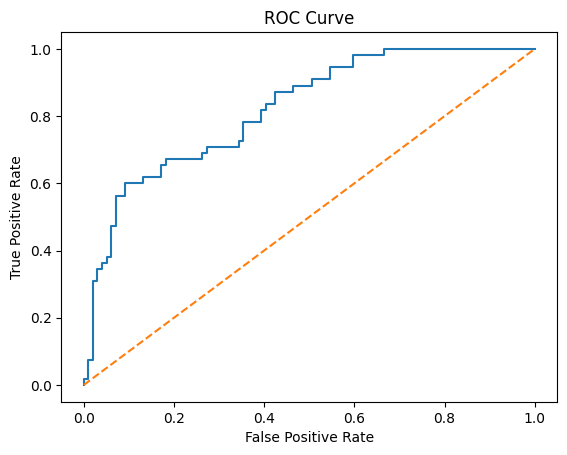

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC:", round(auc, 3))

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(round(auc, 3)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(x_test)
y_prob_rf = rf_model.predict_proba(x_test)[:,1]

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", round(accuracy_rf, 3))
print("Random Forest AUC:", round(auc_rf, 3))

Random Forest Accuracy: 0.747
Random Forest AUC: 0.834


**EVALUATING THE RANDOM FOREST**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[78 21]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



**TUNE RANDOM FOREST FOR FAIR COMPARISON **

In [ ]:
y_pred_rf_new = (y_prob_rf >= 0.3).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf_new))
print(classification_report(y_test, y_pred_rf_new))

[[62 37]
 [ 7 48]]
              precision    recall  f1-score   support

           0       0.90      0.63      0.74        99
           1       0.56      0.87      0.69        55

    accuracy                           0.71       154
   macro avg       0.73      0.75      0.71       154
weighted avg       0.78      0.71      0.72       154



**CROSS VALIDATION**

K-Fold Cross Validation (k = 5 here)

So I am split the data into 5 different ways

Train and test the model 5 times

Then take the average performance.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

auc_scores = cross_val_score(model, x, y, cv=5, scoring='roc_auc')

print("AUC scores for each fold:", auc_scores)
print("Mean AUC:", auc_scores.mean())

AUC scores for each fold: [0.8137037  0.79907407 0.85259259 0.88358491 0.84301887]
Mean AUC: 0.8383948287910552


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(random_state=42)

auc_scores_rf = cross_val_score(rf_model, x, y, cv=5, scoring='roc_auc')

print("RF AUC scores:", auc_scores_rf)
print("RF Mean AUC:", auc_scores_rf.mean())

RF AUC scores: [0.80731481 0.80212963 0.84351852 0.88603774 0.81849057]
RF Mean AUC: 0.8314982529699512


**Adding Decision Tree for more comparison**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Train model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(x_test)
y_prob_dt = dt_model.predict_proba(x_test)[:,1]

# Evaluation
accuracy_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Accuracy:", round(accuracy_dt, 3))
print("Decision Tree AUC:", round(auc_dt, 3))

Decision Tree Accuracy: 0.721
Decision Tree AUC: 0.702


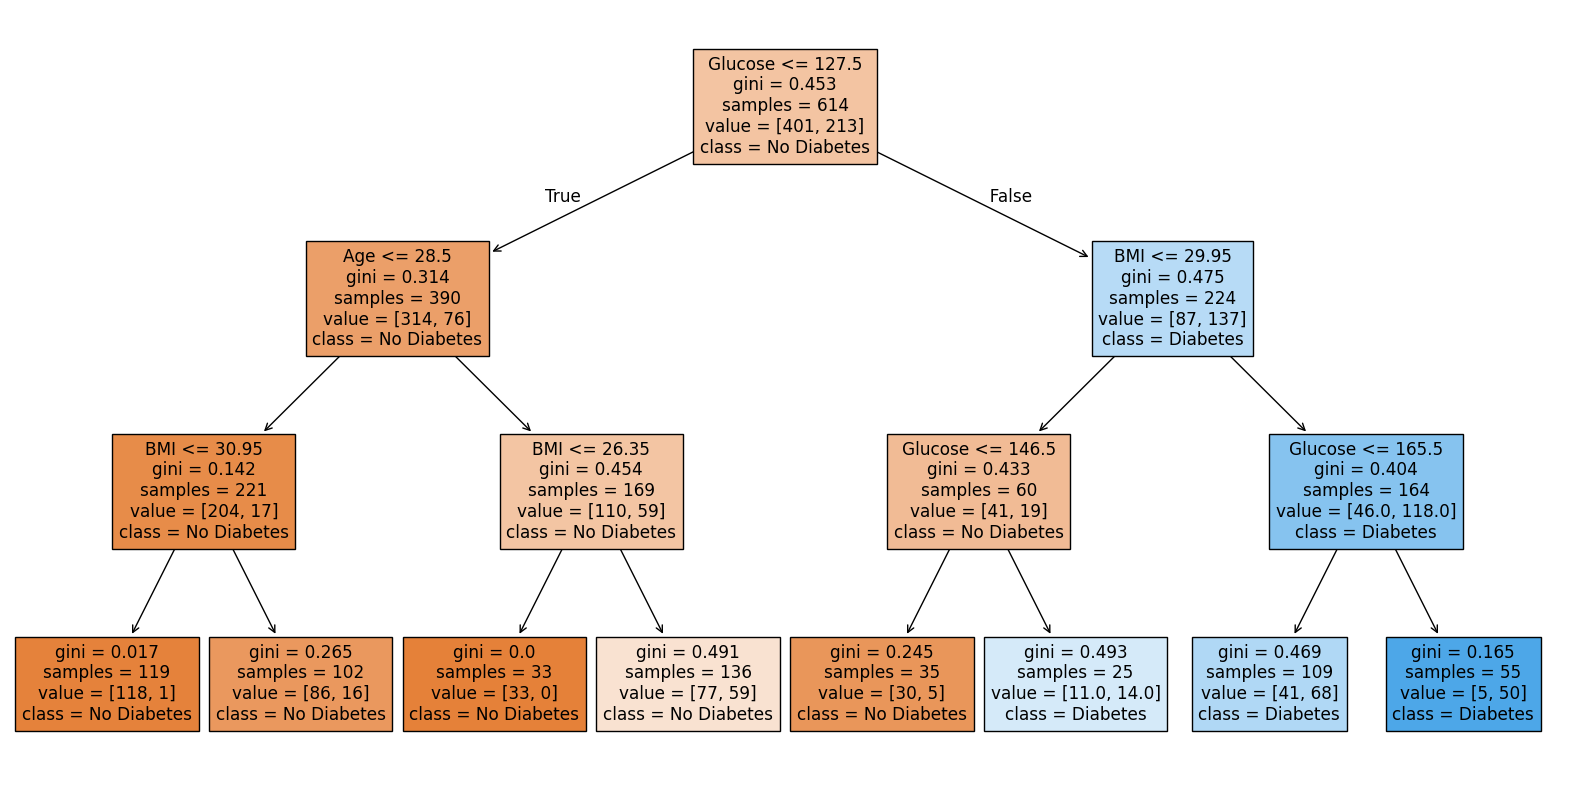

In [ ]:
dt_model_small = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model_small.fit(x_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_model_small, feature_names=x.columns,
          class_names=["No Diabetes","Diabetes"],
          filled=True)
plt.show()

**Create KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(x_test_scaled)
y_prob_knn = knn_model.predict_proba(x_test_scaled)[:,1]

# Evaluate
accuracy_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("KNN Accuracy:", round(accuracy_knn, 3))
print("KNN AUC:", round(auc_knn, 3))

KNN Accuracy: 0.721
KNN AUC: 0.763
